In [1]:
import os
import kagglehub

print("正在下载数据集，请稍候...")
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(f"数据集已下载到: {path}")

data_path = os.path.join(path, "chest_xray")
print("\nchest_xray 内的文件夹:", os.listdir(data_path))
print()

for folder in ['train', 'test', 'val']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        cls_path = os.path.join(data_path, folder, cls)
        if os.path.exists(cls_path):
            num = len(os.listdir(cls_path))
            print(f"{folder}/{cls}: {num} 张图片")
    print()

正在下载数据集，请稍候...
数据集已下载到: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia

chest_xray 内的文件夹: ['chest_xray', '__MACOSX', 'val', 'test', 'train']

train/NORMAL: 1341 张图片
train/PNEUMONIA: 3875 张图片

test/NORMAL: 234 张图片
test/PNEUMONIA: 390 张图片

val/NORMAL: 8 张图片
val/PNEUMONIA: 8 张图片



In [2]:
import os

# 用你第一个单元格已经验证过的路径
data_root = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia"

# 先看看这个路径下到底有什么
print("=== 根目录内容 ===")
print(os.listdir(data_root))
print()

=== 根目录内容 ===
['chest_xray']



In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 第一步：设置路径（修正版，加上 chest_xray）
# ============================================================
data_root = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
train_dir = os.path.join(data_root, "train")
test_dir = os.path.join(data_root, "test")

print("=== 检查路径 ===")
print("train 路径存在:", os.path.exists(train_dir))
print("test 路径存在:", os.path.exists(test_dir))
print()

# ============================================================
# 第二步：收集 train 文件夹下所有图片路径和标签
# ============================================================
print("正在收集训练集图片路径...")
filepaths = []
labels = []

for cls in ['NORMAL', 'PNEUMONIA']:
    cls_dir = os.path.join(train_dir, cls)
    print(f"  正在读取: {cls_dir}")
    fnames = os.listdir(cls_dir)
    print(f"  找到 {len(fnames)} 个文件")
    for fname in fnames:
        filepaths.append(os.path.join(cls_dir, fname))
        labels.append(cls)

print(f"\n总图片数: {len(filepaths)}")
print(f"NORMAL: {labels.count('NORMAL')} 张")
print(f"PNEUMONIA: {labels.count('PNEUMONIA')} 张")

# ============================================================
# 第三步：按 8:2 划分训练集和验证集（作业要求）
# ============================================================
print("\n正在按 8:2 划分训练集/验证集...")
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    filepaths, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"新训练集: {len(X_train_paths)} 张")
print(f"  NORMAL: {y_train.count('NORMAL')}, PNEUMONIA: {y_train.count('PNEUMONIA')}")
print(f"新验证集: {len(X_val_paths)} 张")
print(f"  NORMAL: {y_val.count('NORMAL')}, PNEUMONIA: {y_val.count('PNEUMONIA')}")

# ============================================================
# 第四步：创建数据生成器（数据增强 + 归一化）
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 32

# 训练数据：数据增强 + 归一化
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 验证/测试数据：只归一化，不做增强
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

# 用 DataFrame 格式传给生成器
train_df = pd.DataFrame({'filepath': X_train_paths, 'label': y_train})
val_df = pd.DataFrame({'filepath': X_val_paths, 'label': y_val})

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# 测试数据生成器（保留原始 test 文件夹）
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n===== 数据准备完成！ =====")
print(f"训练批次: {len(train_generator)} 批")
print(f"验证批次: {len(val_generator)} 批")
print(f"测试批次: {len(test_generator)} 批")

2026-05-01 05:45:48.183395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777614348.598492      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777614348.708739      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777614349.651099      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777614349.651161      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777614349.651164      16 computation_placer.cc:177] computation placer alr

=== 检查路径 ===
train 路径存在: True
test 路径存在: True

正在收集训练集图片路径...
  正在读取: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL
  找到 1341 个文件
  正在读取: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA
  找到 3875 个文件

总图片数: 5216
NORMAL: 1341 张
PNEUMONIA: 3875 张

正在按 8:2 划分训练集/验证集...
新训练集: 4172 张
  NORMAL: 1073, PNEUMONIA: 3099
新验证集: 1044 张
  NORMAL: 268, PNEUMONIA: 776
Found 4172 validated image filenames belonging to 2 classes.
Found 1044 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.

===== 数据准备完成！ =====
训练批次: 131 批
验证批次: 33 批
测试批次: 20 批


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# ============================================================
# 搭建 CNN 模型（方案 A：自建简单 CNN）
# ============================================================
model = Sequential([
    Input(shape=(224, 224, 3)),
    
    # 第一个卷积块
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    
    # 第二个卷积块
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    
    # 第三个卷积块
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    
    # 第四个卷积块
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    
    # 全连接层
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # 二分类输出
])

# 编译模型
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 打印模型结构
model.summary()

2026-05-01 05:46:50.781924: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,233,985 (50.48 MB)

 Trainable params: 13,233,985 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# ============================================================
# 设置训练参数
# ============================================================
EPOCHS = 20

# 早停：验证损失连续3轮不下降就停止，防止过拟合
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("开始训练模型...")
print(f"训练集: {train_generator.n} 张图片")
print(f"验证集: {val_generator.n} 张图片")
print(f"每轮 {len(train_generator)} 个批次")
print("="*50)

# ============================================================
# 训练模型
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

print("\n===== 训练完成！ =====")
print(f"最终训练轮数: {len(history.history['loss'])}")

开始训练模型...
训练集: 4172 张图片
验证集: 1044 张图片
每轮 131 个批次
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.7434 - loss: 0.5342 - val_accuracy: 0.8822 - val_loss: 0.2733
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.8772 - loss: 0.2828 - val_accuracy: 0.9128 - val_loss: 0.2215
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.8957 - loss: 0.2653 - val_accuracy: 0.9157 - val_loss: 0.2073
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.9026 - loss: 0.2316 - val_accuracy: 0.9186 - val_loss: 0.1854
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9162 - loss: 0.1946 - val_accuracy: 0.9435 - val_loss: 0.1564
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.9142 - loss: 0.2195 - val_accuracy: 0.9368 - val_loss: 0.2046
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.9131 - loss: 0.2180 - val_accuracy: 0.9540 - val_loss: 0.1351
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/

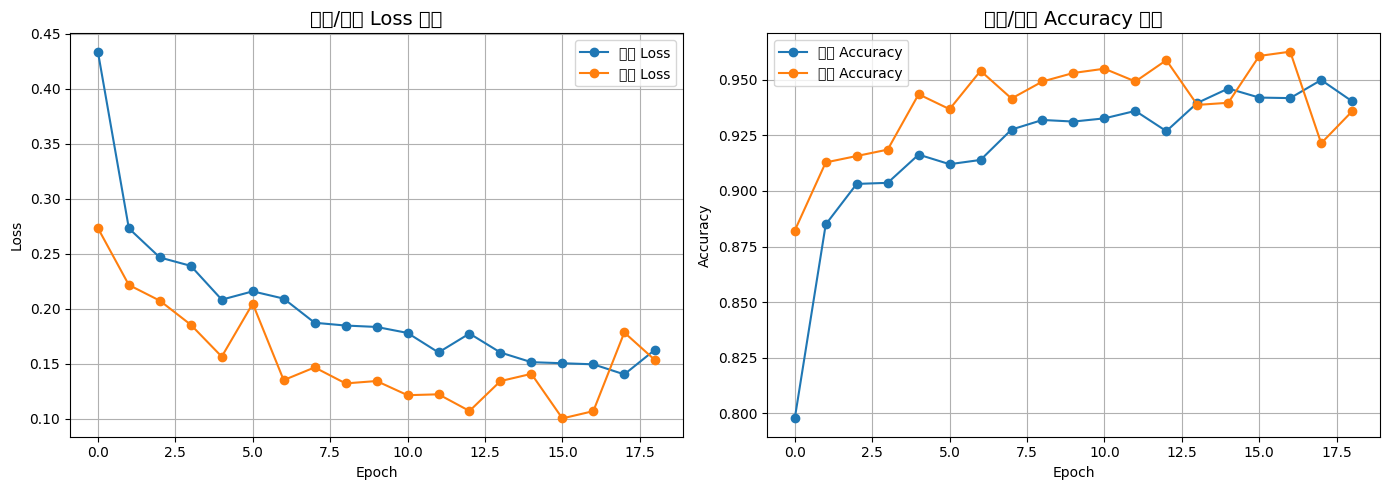

训练曲线已保存为 training_curves.png

正在测试集上评估模型...
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 608ms/step

           测试集评估结果
准确率 (Accuracy):  0.8125
精确率 (Precision): 0.7758
召回率 (Recall):    0.9846
F1 分数 (F1-Score): 0.8678

详细分类报告:
              precision    recall  f1-score   support

      NORMAL       0.95      0.53      0.68       234
   PNEUMONIA       0.78      0.98      0.87       390

    accuracy                           0.81       624
   macro avg       0.86      0.76      0.77       624
weighted avg       0.84      0.81      0.80       624



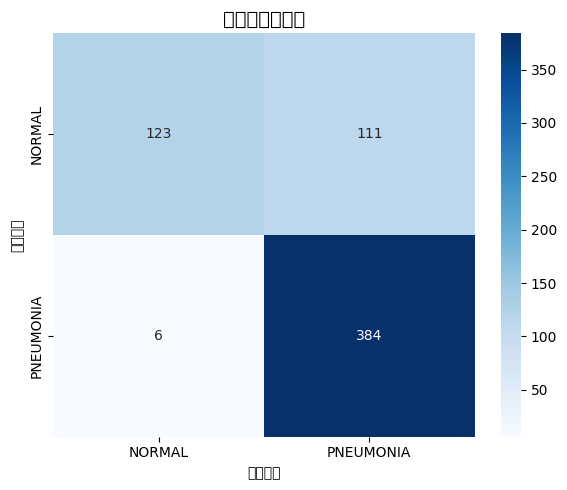

混淆矩阵已保存为 confusion_matrix.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# ============================================================
# 1. 绘制训练/验证 Loss 和 Accuracy 曲线
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 曲线
axes[0].plot(history.history['loss'], label='训练 Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='验证 Loss', marker='o')
axes[0].set_title('训练/验证 Loss 曲线', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy 曲线
axes[1].plot(history.history['accuracy'], label='训练 Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='验证 Accuracy', marker='o')
axes[1].set_title('训练/验证 Accuracy 曲线', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("训练曲线已保存为 training_curves.png")
print()

# ============================================================
# 2. 在测试集上预测并评估
# ============================================================
print("正在测试集上评估模型...")
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

# 计算四项指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n" + "="*50)
print("           测试集评估结果")
print("="*50)
print(f"准确率 (Accuracy):  {accuracy:.4f}")
print(f"精确率 (Precision): {precision:.4f}")
print(f"召回率 (Recall):    {recall:.4f}")
print(f"F1 分数 (F1-Score): {f1:.4f}")
print("="*50)

# 详细分类报告
print("\n详细分类报告:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

# ============================================================
# 3. 绘制混淆矩阵
# ============================================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('测试集混淆矩阵', fontsize=14)
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("混淆矩阵已保存为 confusion_matrix.png")

开始训练模型...
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9425 - loss: 0.1618 - val_accuracy: 0.9540 - val_loss: 0.1127
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9492 - loss: 0.1463 - val_accuracy: 0.9665 - val_loss: 0.0948
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9438 - loss: 0.1520 - val_accuracy: 0.9665 - val_loss: 0.0975
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9461 - loss: 0.1442 - val_accuracy: 0.9588 - val_loss: 0.1045
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9489 - loss: 0.1295 - val_accuracy: 0.9693 - val_loss: 0.0895
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9510 - loss: 0.1327 - val_accuracy: 0.9521 - val_loss: 0.1171
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9483 - loss: 0.1318 - val_accuracy: 0.9674 - val_loss: 0.0899
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9495 - loss: 0.1321 

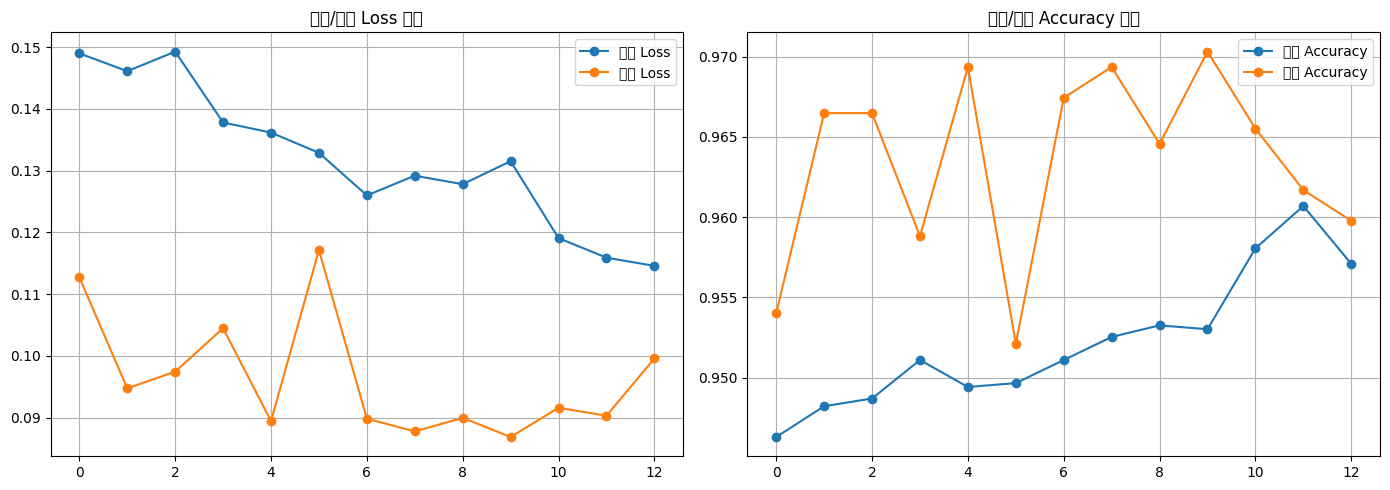

曲线已保存
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 501ms/step

===== 测试集指标 =====
Accuracy:  0.7837
Precision: 0.7457
Recall:    0.9923
F1-Score:  0.8515


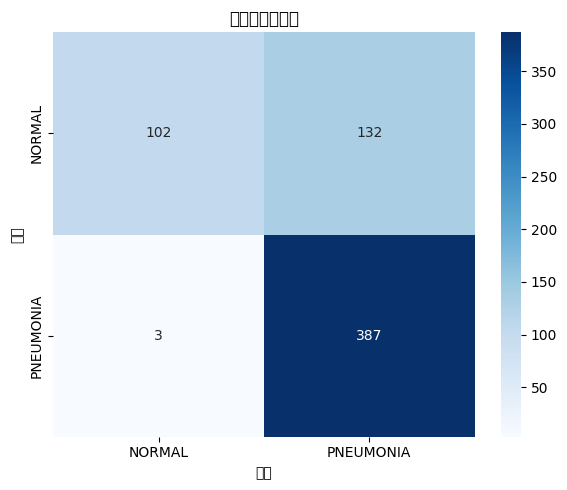

混淆矩阵已保存


In [7]:
# ============================================================
# 训练 + 评估 一条龙
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

# -------------------- 训练 --------------------
EPOCHS = 20
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("开始训练模型...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)
print("训练完成！")

# -------------------- 评估 --------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 画曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='训练 Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='验证 Loss', marker='o')
axes[0].set_title('训练/验证 Loss 曲线')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history.history['accuracy'], label='训练 Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='验证 Accuracy', marker='o')
axes[1].set_title('训练/验证 Accuracy 曲线')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()
print("曲线已保存")

# 测试集评估
test_generator.reset()
y_pred = (model.predict(test_generator) > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\n===== 测试集指标 =====")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL','PNEUMONIA'], yticklabels=['NORMAL','PNEUMONIA'])
plt.title('测试集混淆矩阵'); plt.xlabel('预测'); plt.ylabel('真实')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()
print("混淆矩阵已保存")

=== 收集训练集图片 ===
总图片: 5216 (NORMAL: 1341, PNEUMONIA: 3875)
训练集: 4172, 验证集: 1044
Found 4172 validated image filenames belonging to 2 classes.
Found 1044 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,233,985 (50.48 MB)

 Trainable params: 13,233,985 (50.48 MB)

 Non-trainable params: 0 (0.00 B)


开始训练...
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.7601 - loss: 0.5154 - val_accuracy: 0.8927 - val_loss: 0.2410
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.8918 - loss: 0.2653 - val_accuracy: 0.9013 - val_loss: 0.2270
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.8948 - loss: 0.2607 - val_accuracy: 0.9377 - val_loss: 0.1720
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.8996 - loss: 0.2400 - val_accuracy: 0.9052 - val_loss: 0.2111
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9020 - loss: 0.2296 - val_accuracy: 0.8908 - val_loss: 0.2247
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9249 - loss: 0.1973 - val_accuracy: 0.9387 - val_loss: 0.1638
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9221 - loss: 0.1956 - val_accuracy: 0.9138 - val_loss: 0.1795
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9333 - loss: 0.1722 -

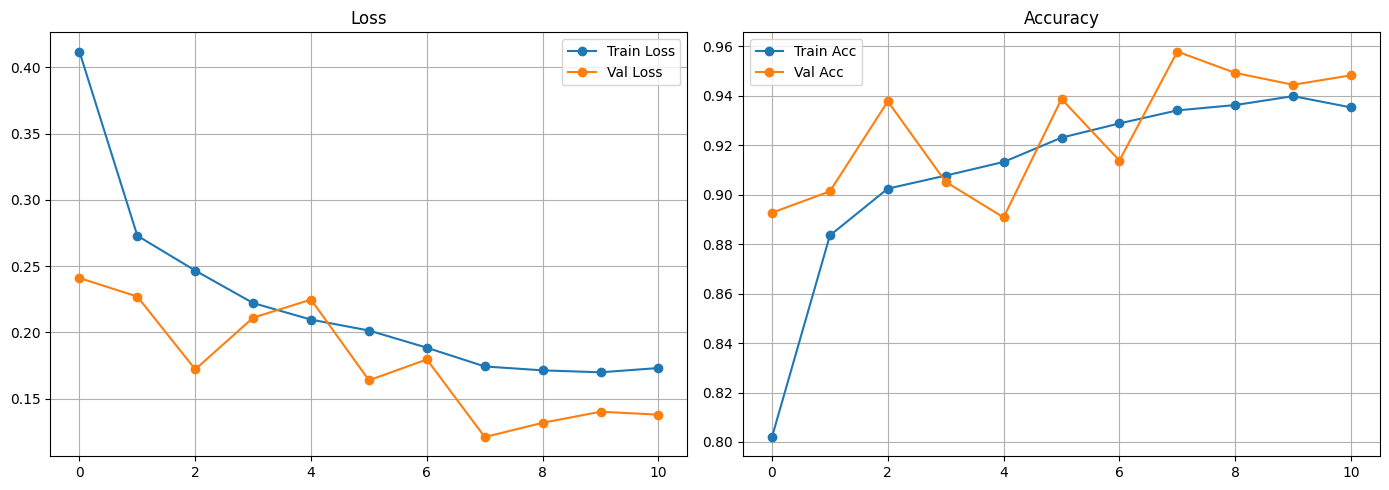

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 482ms/step

===== 测试集指标 =====
Accuracy:  0.7965
Precision: 0.7604
Recall:    0.9846
F1-Score:  0.8581


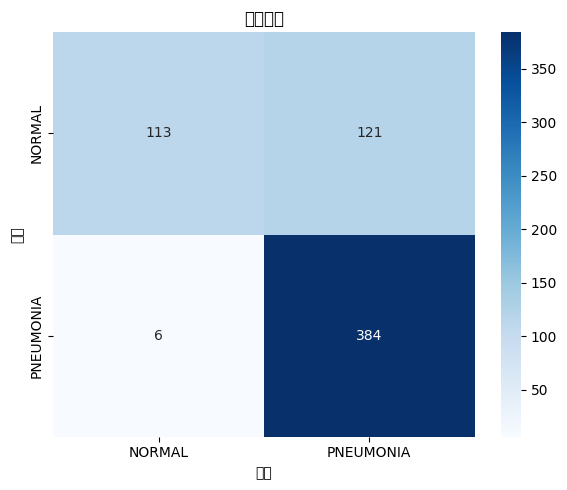


全部完成！两张图已保存。


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. 数据准备
# ============================================================
data_root = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
train_dir = os.path.join(data_root, "train")
test_dir = os.path.join(data_root, "test")

print("=== 收集训练集图片 ===")
filepaths, labels = [], []
for cls in ['NORMAL', 'PNEUMONIA']:
    cls_dir = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_dir):
        filepaths.append(os.path.join(cls_dir, fname))
        labels.append(cls)
print(f"总图片: {len(filepaths)} (NORMAL: {labels.count('NORMAL')}, PNEUMONIA: {labels.count('PNEUMONIA')})")

# 8:2 划分
X_train, X_val, y_train, y_val = train_test_split(filepaths, labels, test_size=0.2, random_state=42, stratify=labels)
print(f"训练集: {len(X_train)}, 验证集: {len(X_val)}")

# 数据生成器
IMG_SIZE, BATCH_SIZE = 224, 32
train_datagen = ImageDataGenerator(rescale=1.0/255, rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_dataframe(pd.DataFrame({'fp': X_train, 'lb': y_train}),
    x_col='fp', y_col='lb', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='binary', shuffle=True)
val_generator = val_test_datagen.flow_from_dataframe(pd.DataFrame({'fp': X_val, 'lb': y_val}),
    x_col='fp', y_col='lb', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)
test_generator = val_test_datagen.flow_from_directory(test_dir,
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

# ============================================================
# 2. 搭建模型
# ============================================================
model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32,(3,3),activation='relu',padding='same'), MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu',padding='same'), MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu',padding='same'), MaxPooling2D(2,2),
    Conv2D(256,(3,3),activation='relu',padding='same'), MaxPooling2D(2,2),
    Flatten(), Dense(256,activation='relu'), Dropout(0.5), Dense(1,activation='sigmoid')
])
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ============================================================
# 3. 训练
# ============================================================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print("\n开始训练...")
history = model.fit(train_generator, validation_data=val_generator, epochs=20, callbacks=[early_stop], verbose=1)
print("训练完成！")

# ============================================================
# 4. 评估 + 画图
# ============================================================
# 曲线
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(history.history['loss'],label='Train Loss',marker='o')
axes[0].plot(history.history['val_loss'],label='Val Loss',marker='o')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history.history['accuracy'],label='Train Acc',marker='o')
axes[1].plot(history.history['val_accuracy'],label='Val Acc',marker='o')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig('training_curves.png',dpi=150); plt.show()

# 测试集
test_generator.reset()
y_pred = (model.predict(test_generator) > 0.5).astype(int).flatten()
y_true = test_generator.classes
print("\n===== 测试集指标 =====")
print(f"Accuracy:  {accuracy_score(y_true,y_pred):.4f}")
print(f"Precision: {precision_score(y_true,y_pred):.4f}")
print(f"Recall:    {recall_score(y_true,y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true,y_pred):.4f}")

# 混淆矩阵
cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['NORMAL','PNEUMONIA'],yticklabels=['NORMAL','PNEUMONIA'])
plt.title('混淆矩阵'); plt.xlabel('预测'); plt.ylabel('真实')
plt.tight_layout(); plt.savefig('confusion_matrix.png',dpi=150); plt.show()

print("\n全部完成！两张图已保存。")